# Analyzation of Wind Speed for Masked Forecasts

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from typing import Union, Optional, List

In [20]:
def plot_mean_wind_speed_comparison(
    masked_folder: str,
    input_path: Union[str, os.PathLike],
    region_lat: slice = slice(55.0, 53.0),
    region_lon: slice = slice(7.5, 10.5),
    title: str = "Mean Wind Speed at 22:00 UTC over North Germany (10m) – Feature Occlusion",
    rename_map: Optional[dict] = None,
    order: Optional[List[str]] = None,
):

    def mean_wind_speed(ds, time_sel=None):
        if time_sel is not None:
            u10 = ds["10m_u_component_of_wind"].isel(time=time_sel)
            v10 = ds["10m_v_component_of_wind"].isel(time=time_sel)
        else:
            u10 = ds["10m_u_component_of_wind"].squeeze()
            v10 = ds["10m_v_component_of_wind"].squeeze()

        wind_speed = np.sqrt(u10**2 + v10**2)
        return wind_speed.sel(lat=region_lat, lon=region_lon).mean().item()

    wind_means = {}

    # Unmasked
    unmasked_ds = xr.open_dataset(input_path)
    if "time" in unmasked_ds and unmasked_ds.time.size > 1:
        try:
            time_sel = int(np.where(unmasked_ds.time.dt.hour == 22)[0][0])
        except (AttributeError, IndexError):
            time_sel = 0
    else:
        time_sel = None

    unmasked_mean = mean_wind_speed(unmasked_ds, time_sel)

    # Masked
    for fname in sorted(os.listdir(masked_folder)):
        if not fname.endswith(".nc"):
            continue
        path = os.path.join(masked_folder, fname)
        ds = xr.open_dataset(path)
        label = fname.replace("masked_", "").replace(".nc", "")
        display_label = rename_map[label] if rename_map and label in rename_map else label
        wind_means[display_label] = mean_wind_speed(ds)

    # Apply custom order if provided
    if order:
        labels = [lbl for lbl in order if lbl in wind_means]
    else:
        labels = list(wind_means.keys())

    values = [wind_means[lbl] for lbl in labels]

    # Plot
    plt.figure(figsize=(10, 6))
    plt.bar(labels, values, color='skyblue')
    plt.axhline(unmasked_mean, color='black', linestyle='--', label='Unmasked Reference')
    plt.ylabel("10m Wind Speed at 22:00 UTC (m/s)")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [2]:
input_path="../data/prediction_zeynep_22/input_data/graphcast_ready_input_zeynep_22_graphcast_small.nc"
original_prediction_path="../data/prediction_zeynep_22/predictions/zeynep_22_prediction_graphcast_small.nc"

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_64929/2240459380.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_64929/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_64929/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipyker

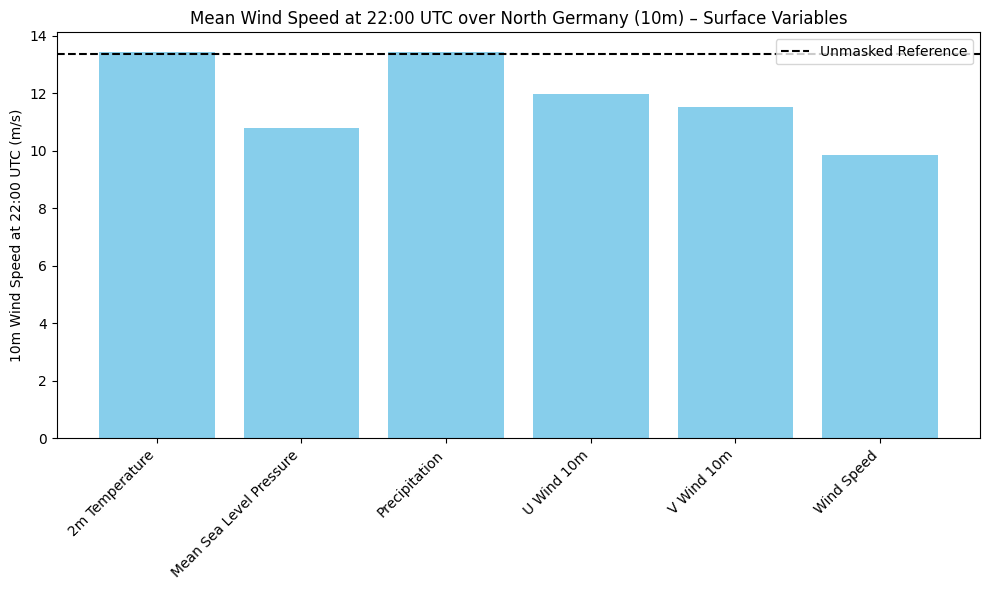

In [15]:
rename_map = {
    "2m_temperature_levnone_regnone_tnone": "2m Temperature",
    "10m_u_component_of_wind_levnone_regnone_tnone": "U Wind 10m",
    "10m_v_component_of_wind_levnone_regnone_tnone": "V Wind 10m",
    "mean_sea_level_pressure_levnone_regnone_tnone": "Mean Sea Level Pressure",
    "total_precipitation_6hr_levnone_regnone_tnone": "Precipitation",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone_regnone_tnone": "Wind Speed"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/surface_variables",
    input_path=original_prediction_path,
    title = "Mean Wind Speed at 22:00 UTC over North Germany (10m) – Surface Variables",
    rename_map=rename_map,
    order=[
        "2m Temperature",
        "Mean Sea Level Pressure",
        "Precipitation",
        "U Wind 10m",
        "V Wind 10m",
        "Wind Speed"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_64929/2240459380.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_64929/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_64929/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipyker

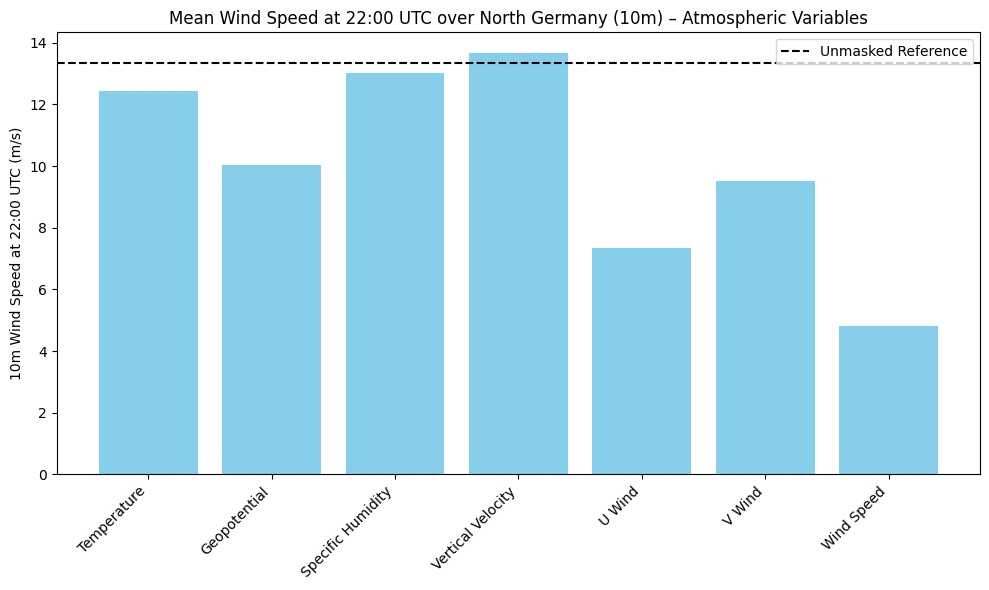

In [14]:
rename_map = {
    "temperature_levnone_regnone_tnone": "Temperature",
    "u_component_of_wind_levnone_regnone_tnone": "U Wind",
    "v_component_of_wind_levnone_regnone_tnone": "V Wind",
    "geopotential_levnone_regnone_tnone": "Geopotential",
    "vertical_velocity_levnone_regnone_tnone": "Vertical Velocity",
    "specific_humidity_levnone_regnone_tnone": "Specific Humidity",
    "('u_component_of_wind', 'v_component_of_wind')_levnone_regnone_tnone": "Wind Speed"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/atmospheric_variables",
    input_path=original_prediction_path,
    title = "Mean Wind Speed at 22:00 UTC over North Germany (10m) – Atmospheric Variables",
    rename_map=rename_map,
    order=[
        "Unmasked",
        "Temperature",
        "Geopotential",
        "Specific Humidity",
        "Vertical Velocity",
        "U Wind",
        "V Wind",
        "Wind Speed"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_53912/2240459380.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_53912/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_53912/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipyker

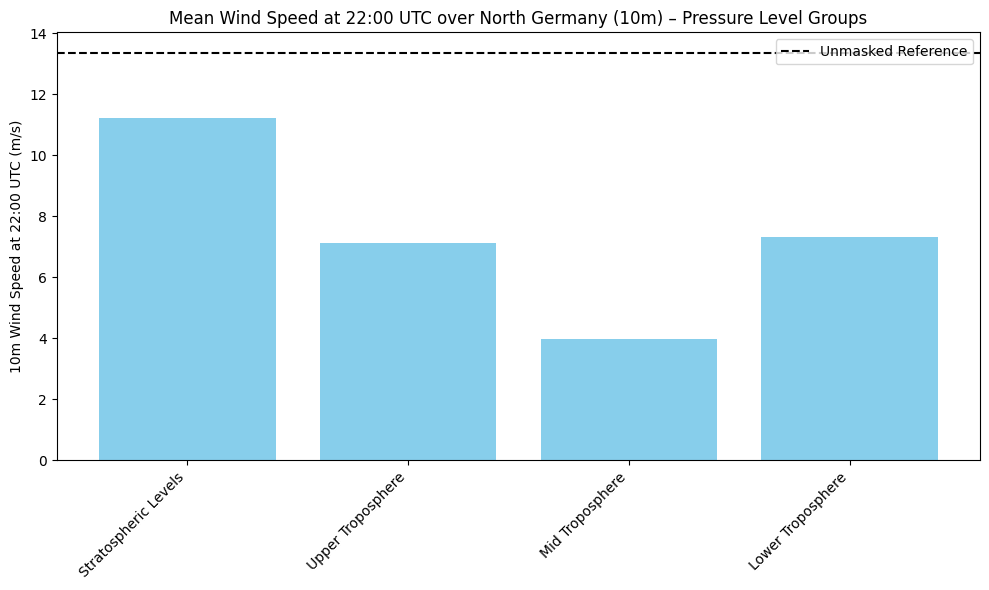

In [61]:
rename_map = {
    "none_lev(50, 100, 150, 200)_regnone_tnone": "Stratospheric Levels",
    "none_lev(250, 300, 400)_regnone_tnone": "Upper Troposphere",
    "none_lev(500, 600, 700)_regnone_tnone": "Mid Troposphere",
    "none_lev(850, 925, 1000)_regnone_tnone": "Lower Troposphere"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/pressure_level_groups",
    input_path=original_prediction_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Pressure Level Groups",
    rename_map=rename_map,
    order=[
        "Unmasked",
        "Stratospheric Levels",
        "Upper Troposphere",
        "Mid Troposphere",
        "Lower Troposphere"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_53912/2240459380.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_53912/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_53912/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipyker

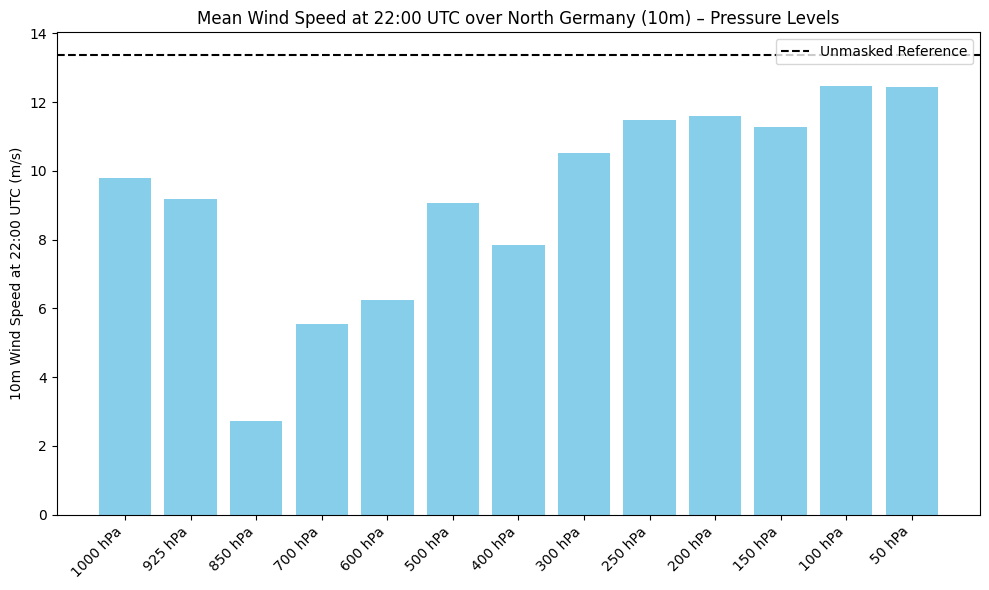

In [62]:
rename_map = {
    "none_lev1000_regnone_tnone": "1000 hPa",
    "none_lev925_regnone_tnone": "925 hPa",
    "none_lev850_regnone_tnone": "850 hPa",
    "none_lev700_regnone_tnone": "700 hPa",
    "none_lev600_regnone_tnone": "600 hPa",
    "none_lev500_regnone_tnone": "500 hPa",
    "none_lev400_regnone_tnone": "400 hPa",
    "none_lev300_regnone_tnone": "300 hPa",
    "none_lev250_regnone_tnone": "250 hPa",
    "none_lev200_regnone_tnone": "200 hPa",
    "none_lev150_regnone_tnone": "150 hPa",
    "none_lev100_regnone_tnone": "100 hPa",
    "none_lev50_regnone_tnone": "50 hPa"
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/pressure_levels",
    input_path=original_prediction_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Pressure Levels",
    rename_map=rename_map,
    order=[
        "Unmasked",
        "1000 hPa",
        "925 hPa",
        "850 hPa",
        "700 hPa",
        "600 hPa",
        "500 hPa",
        "400 hPa",
        "300 hPa",
        "250 hPa",
        "200 hPa",
        "150 hPa",
        "100 hPa",
        "50 hPa"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_64929/2240459380.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_64929/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_64929/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipyker

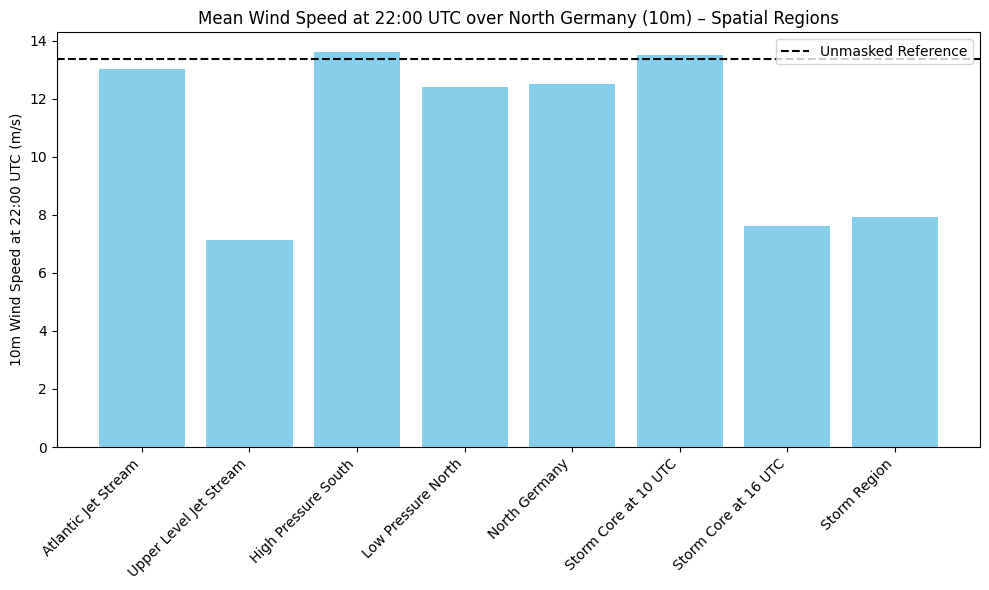

In [16]:
rename_map = {
    "none_levnone_regatlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "none_levnone_regupper_level_jet_stream_tnone": "Upper Level Jet Stream",
    "none_levnone_reghigh_pressure_south_tnone": "High Pressure South",
    "none_levnone_reglow_pressure_north_tnone": "Low Pressure North",
    "none_levnone_regnorth_germany_tnone": "North Germany",
    "none_levnone_regstorm_core_10utc_tnone": "Storm Core at 10 UTC",
    "none_levnone_regstorm_core_16utc_tnone": "Storm Core at 16 UTC",
    "none_levnone_regstorm_region_tnone": "Storm Region",
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/spatial_regions",
    input_path=original_prediction_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Spatial Regions",
    rename_map=rename_map,
    order=[
        "Unmasked",
        "Atlantic Jet Stream",
        "Upper Level Jet Stream",
        "High Pressure South",
        "Low Pressure North",
        "North Germany",
        "Storm Core at 10 UTC",
        "Storm Core at 16 UTC",
        "Storm Region"
    ]
)

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_53912/2240459380.py:25: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_53912/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_53912/2240459380.py:41: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)


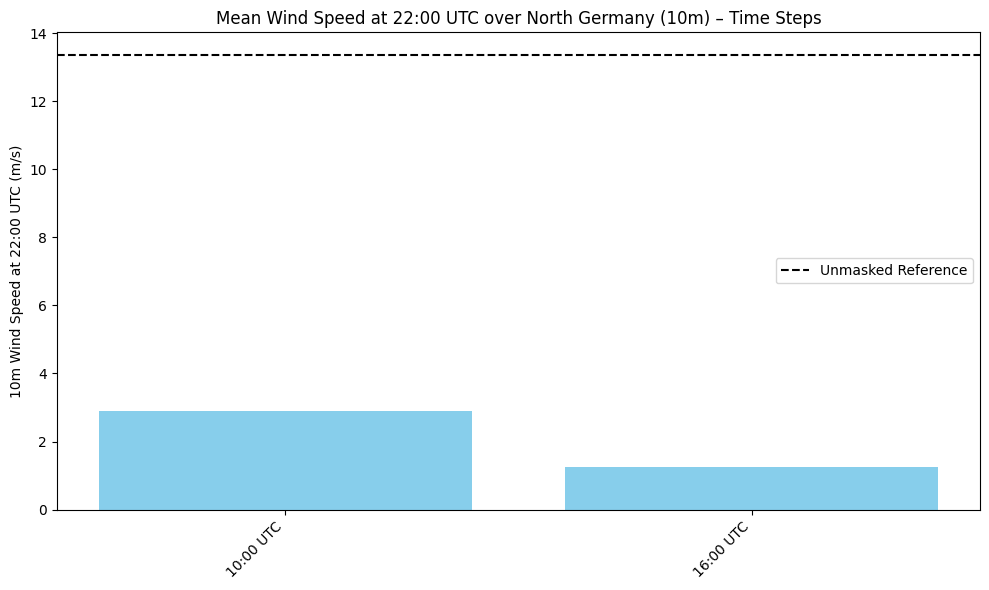

In [64]:
rename_map = {
    "none_levnone_regnone_t0": "10:00 UTC",
    "none_levnone_regnone_t1": "16:00 UTC",
}

plot_mean_wind_speed_comparison(
    masked_folder="../data/feature_occlusion/time_steps",
    input_path=original_prediction_path,
    title="Mean Wind Speed at 22:00 UTC over North Germany (10m) – Time Steps",
    rename_map=rename_map
)

## Multiple Features

In [4]:
import os
import re
import ast
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from typing import Union, Dict, Optional, List

In [5]:
def plot_feature_grouped_heatmap(
    masked_folder: Union[str, os.PathLike],
    reference_path: Union[str, os.PathLike],
    group_x: str = "Pressure Levels",
    group_y: str = "Variable",
    region_lat: slice = slice(55.0, 53.0),
    region_lon: slice = slice(7.5, 10.5),
    title: str = "Δ Wind Speed – Grouped Heatmap",
    rename_map: Optional[Dict[str, str]] = None,
    order: Optional[Dict[str, List[str]]] = None
):
    def parse_filename_general(fname):
        name = fname.replace("masked_", "").replace(".nc", "")
        groups = {}

        stop_tokens = ["lev(", "reg", "t"]
        for token in stop_tokens:
            token_idx = name.find(token)
            if token_idx != -1:
                var_str = name[:token_idx].rstrip("_")
                name = name[token_idx:]
                break
        else:
            var_str = name
            name = ""

        try:
            parsed = ast.literal_eval(var_str)
            groups["Variable"] = "\n".join(parsed) if isinstance(parsed, tuple) else parsed
        except Exception:
            groups["Variable"] = var_str

        group_patterns = {
            "Pressure Levels": r"lev\((.*?)\)",
            "Region": r"reg([a-zA-Z0-9_]+)",
            "Time Step": r"t([0-9\-]+|none)"
        }

        for key, pattern in group_patterns.items():
            m = re.search(pattern, name)
            if m:
                groups[key] = m.group(1)

        return groups

    def mean_wind_speed(ds):
        u10 = ds["10m_u_component_of_wind"].squeeze()
        v10 = ds["10m_v_component_of_wind"].squeeze()
        wind_speed = np.sqrt(u10**2 + v10**2)
        return wind_speed.sel(lat=region_lat, lon=region_lon).mean().item()

    # Load reference mean wind speed
    reference_ds = xr.open_dataset(reference_path)
    reference_mean = mean_wind_speed(reference_ds)

    records = []

    # Loop through masked files
    for fname in sorted(os.listdir(masked_folder)):
        if not fname.endswith(".nc"):
            continue

        groups = parse_filename_general(fname)
        if group_x not in groups or group_y not in groups:
            continue

        x_val = rename_map.get(groups[group_x], groups[group_x]) if rename_map else groups[group_x]
        y_val = rename_map.get(groups[group_y], groups[group_y]) if rename_map else groups[group_y]

        ds = xr.open_dataset(os.path.join(masked_folder, fname))
        value = mean_wind_speed(ds)
        delta = value - reference_mean
        records.append((y_val, x_val, delta))

    if not records:
        raise ValueError("No valid data records were parsed. Check filename patterns and group names.")

    df = pd.DataFrame(records, columns=[group_y, group_x, "Δ Wind Speed"])

    if order:
        if group_y in order:
            df[group_y] = pd.Categorical(df[group_y], categories=order[group_y], ordered=True)
        if group_x in order:
            df[group_x] = pd.Categorical(df[group_x], categories=order[group_x], ordered=True)

    pivot_df = df.pivot_table(index=group_y, columns=group_x, values="Δ Wind Speed", aggfunc="mean")

    fig, ax = plt.subplots(figsize=(14, 8))
    im = ax.imshow(pivot_df.values, cmap="coolwarm", vmin=-np.abs(pivot_df.values).max(), vmax=np.abs(pivot_df.values).max())

    ax.set_xticks(np.arange(pivot_df.shape[1]))
    ax.set_yticks(np.arange(pivot_df.shape[0]))
    ax.set_xticklabels(pivot_df.columns)
    ax.set_yticklabels(pivot_df.index)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            val = pivot_df.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Δ Wind Speed (m/s)")

    ax.set_title(title)
    ax.set_xlabel(group_x)
    ax.set_ylabel(group_y)
    plt.tight_layout()
    plt.show()


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_5428/3916800531.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_5428/3916800531.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_5428/3916800531.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, f

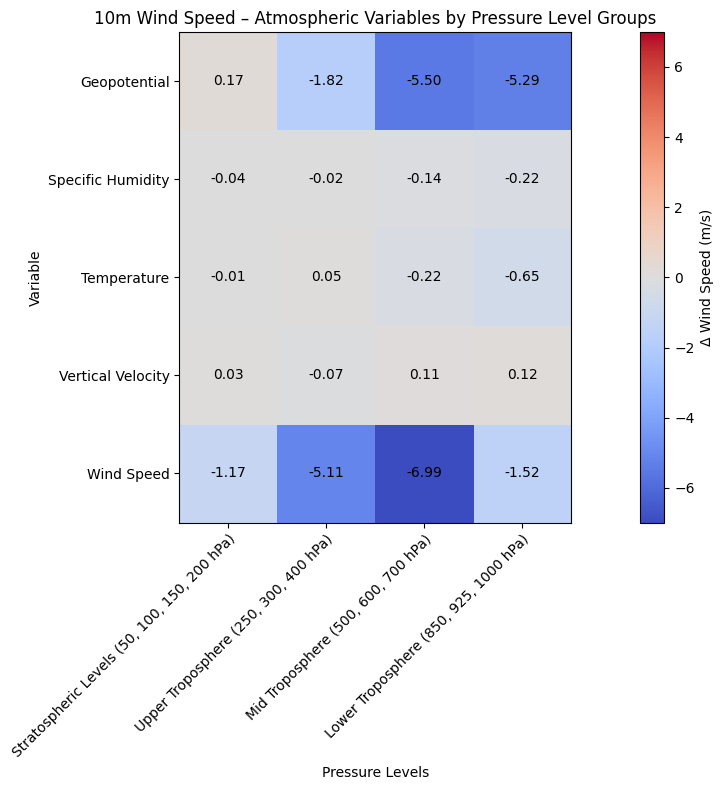

In [6]:
rename_map = {
    "geopotential": "Geopotential",
    "temperature": "Temperature",
    "specific_humidity": "Specific Humidity",
    # "u_component_of_wind": "U Wind",
    # "v_component_of_wind": "V Wind",
    "u_component_of_wind\nv_component_of_wind": "Wind Speed",
    "vertical_velocity": "Vertical Velocity",

    "50, 100, 150, 200": "Stratospheric Levels (50, 100, 150, 200 hPa)",
    "250, 300, 400": "Upper Troposphere (250, 300, 400 hPa)",
    "500, 600, 700": "Mid Troposphere (500, 600, 700 hPa)",
    "850, 925, 1000": "Lower Troposphere (850, 925, 1000 hPa)"
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/pressure_level_groups_atmospheric_variables",
    reference_path=original_prediction_path,
    group_x="Pressure Levels",
    group_y="Variable",
    title="10m Wind Speed – Atmospheric Variables by Pressure Level Groups",
    rename_map=rename_map,
    order={
        "Pressure Levels": [
            "Stratospheric Levels (50, 100, 150, 200 hPa)",
            "Upper Troposphere (250, 300, 400 hPa)",
            "Mid Troposphere (500, 600, 700 hPa)",
            "Lower Troposphere (850, 925, 1000 hPa)"
        ],
    }
)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_5428/3916800531.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_5428/3916800531.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_5428/3916800531.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, f

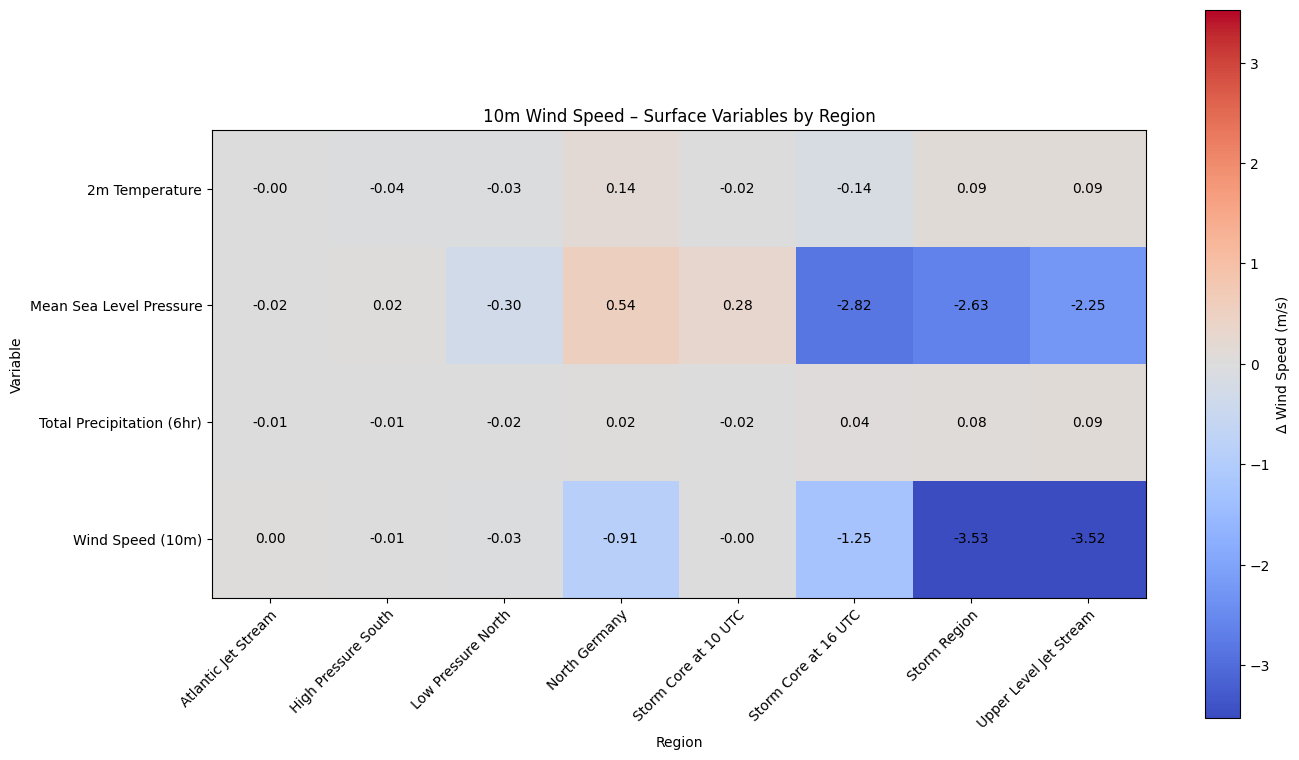

In [7]:
rename_map = {
    "2m_temperature_levnone": "2m Temperature",
    # "10m_u_component_of_wind_levnone": "U Wind 10m",
    # "10m_v_component_of_wind_levnone": "V Wind 10m",
    "mean_sea_level_pressure_levnone": "Mean Sea Level Pressure",
    "total_precipitation_6hr_levnone": "Total Precipitation (6hr)",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone": "Wind Speed (10m)",

    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "upper_level_jet_stream_tnone": "Upper Level Jet Stream",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "north_germany_tnone": "North Germany",
    "storm_core_10utc_tnone": "Storm Core at 10 UTC",
    "storm_core_16utc_tnone": "Storm Core at 16 UTC",
    "storm_region_tnone": "Storm Region"
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/regions_surface_variables",
    reference_path=original_prediction_path,
    group_x="Region",
    title="10m Wind Speed – Surface Variables by Region",
    rename_map=rename_map,
)


/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_5428/3916800531.py:53: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_5428/3916800531.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_5428/3916800531.py:70: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, f

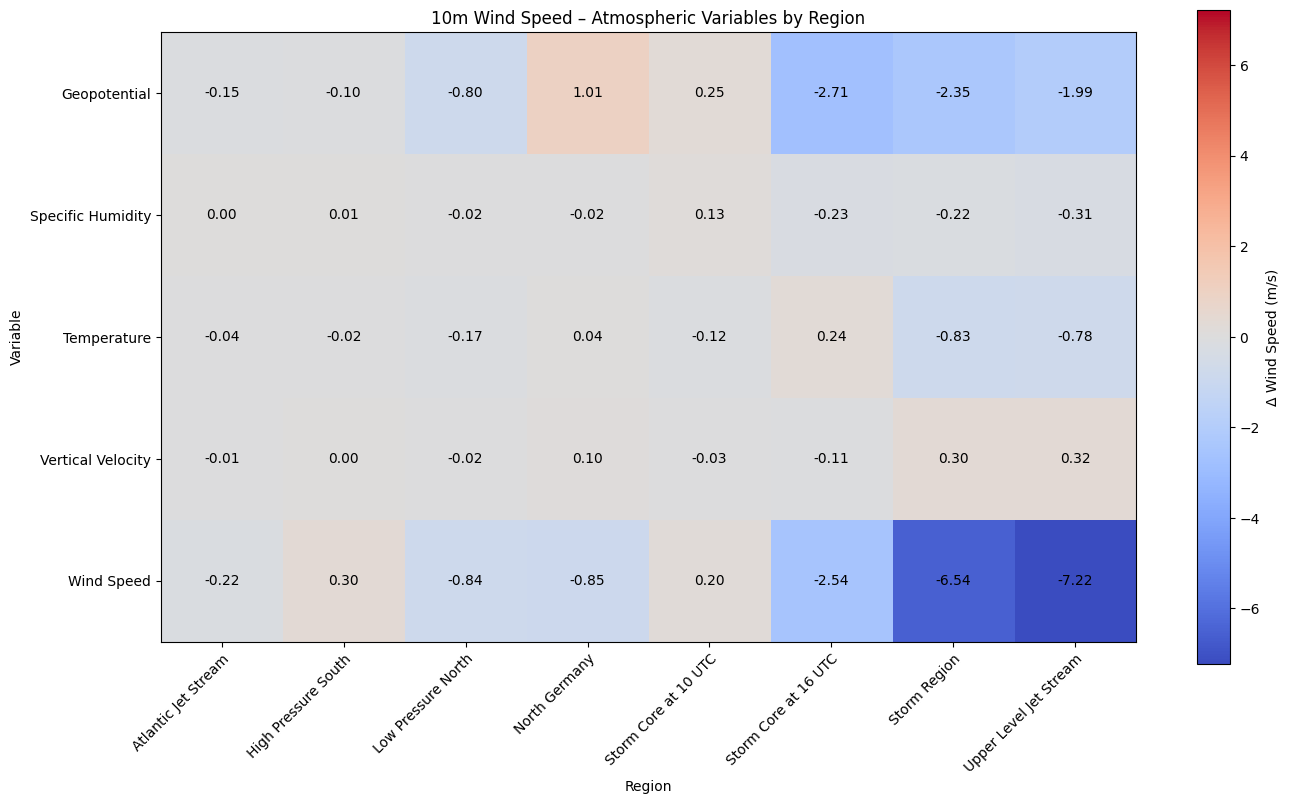

In [8]:
rename_map = {
    "geopotential_levnone": "Geopotential",
    "temperature_levnone": "Temperature",
    "specific_humidity_levnone": "Specific Humidity",
    # "u_component_of_wind_levnone": "U Wind",
    # "v_component_of_wind_levnone": "V Wind",
    "('u_component_of_wind', 'v_component_of_wind')_levnone": "Wind Speed",
    "vertical_velocity_levnone": "Vertical Velocity",

    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "upper_level_jet_stream_tnone": "Upper Level Jet Stream",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "north_germany_tnone": "North Germany",
    "storm_core_10utc_tnone": "Storm Core at 10 UTC",
    "storm_core_16utc_tnone": "Storm Core at 16 UTC",
    "storm_region_tnone": "Storm Region"
}

plot_feature_grouped_heatmap(
    masked_folder="../data/feature_occlusion/regions_atmospheric_variables",
    reference_path=original_prediction_path,
    group_x="Region",
    title="10m Wind Speed – Atmospheric Variables by Region",
    rename_map=rename_map,
)


# Tests

In [66]:
# Define file path and region
region_lat = slice(55.0, 53.0)  # North to South
region_lon = slice(7.5, 10.5)   # West to East

# Load the dataset
ds = xr.open_dataset(input_path)

# Find the index for 22:00 UTC
time_sel = int(np.where(ds.time.dt.hour == 22)[0][0])

# Select u and v components at 22:00
u10 = ds["10m_u_component_of_wind"].isel(time=time_sel)
v10 = ds["10m_v_component_of_wind"].isel(time=time_sel)

# Compute wind speed
wind_speed = np.sqrt(u10**2 + v10**2)

# Select region and compute mean
regional_mean = wind_speed.sel(lat=region_lat, lon=region_lon).mean().item()

print(f"Mean 10m wind speed at 22:00 UTC over North Germany: {regional_mean:.2f} m/s")


Mean 10m wind speed at 22:00 UTC over North Germany: 14.72 m/s
